# BFS vs. DFS, From Scratch\n\nBreadth-first and depth-first search are the same algorithm with one line changed: swap the frontier from a queue to a stack. That single change flips the entire character of the search:\n\n- **BFS** (queue) explores everything one step away before anything two steps away. That's exactly what guarantees the first time it reaches the goal, it's found a *shortest* path.\n- **DFS** (stack) commits to one neighbor and rides it as far as it goes, only backtracking when it hits a dead end. No such guarantee — it finds *a* path, not necessarily a short one.\n\nThis notebook implements both from scratch in plain Python — no `networkx` — on a maze generated with the randomized recursive-backtracker algorithm. A pure backtracker maze is a spanning tree (exactly one route between any two cells), which would make BFS and DFS reconstruct the *identical* path every time — so a fraction of the walls get knocked down afterward to add loops, which is what actually gives the two algorithms room to disagree.\n\nThe companion interactive version — same maze generator, animated live — lives at `web/`.

In [1]:
import random
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "text.color": "#ffffff",
})

BFS_COLOR = "#3987e5"
DFS_COLOR = "#d95926"


def generate_maze(rooms, seed, extra_loop_fraction=0.15):
    """Recursive-backtracker maze generation, then a fraction of the remaining
    walls are knocked down to add loops (see the markdown above for why)."""
    rng = random.Random(seed)
    size = 2 * rooms + 1
    open_cells = [[False] * size for _ in range(size)]

    def room_cell(r, c):
        return 2 * r + 1, 2 * c + 1

    visited = [[False] * rooms for _ in range(rooms)]
    stack = [(0, 0)]
    visited[0][0] = True
    sr, sc = room_cell(0, 0)
    open_cells[sr][sc] = True

    dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]

    while stack:
        r, c = stack[-1]
        options = []
        for dr, dc in dirs:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rooms and 0 <= nc < rooms and not visited[nr][nc]:
                options.append((nr, nc, dr, dc))
        if not options:
            stack.pop()
            continue
        nr, nc, dr, dc = rng.choice(options)
        cr, cc = room_cell(r, c)
        open_cells[cr + dr][cc + dc] = True
        ncr, ncc = room_cell(nr, nc)
        open_cells[ncr][ncc] = True
        visited[nr][nc] = True
        stack.append((nr, nc))

    wall_candidates = []
    for r in range(rooms):
        for c in range(rooms):
            cr, cc = room_cell(r, c)
            if c + 1 < rooms and not open_cells[cr][cc + 1]:
                wall_candidates.append((cr, cc + 1))
            if r + 1 < rooms and not open_cells[cr + 1][cc]:
                wall_candidates.append((cr + 1, cc))
    rng.shuffle(wall_candidates)
    for wr, wc in wall_candidates[: int(len(wall_candidates) * extra_loop_fraction)]:
        open_cells[wr][wc] = True

    return open_cells, size


maze, size = generate_maze(rooms=10, seed=1)
print("maze size:", size, "x", size)

maze size: 21 x 21


In [2]:
def neighbors(maze, size, cell):
    r, c = cell
    result = []
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        nr, nc = r + dr, c + dc
        if 0 <= nr < size and 0 <= nc < size and maze[nr][nc]:
            result.append((nr, nc))
    return result


def reconstruct_path(came_from, start, goal):
    if start == goal:
        return [start]
    if goal not in came_from:
        return None
    path = [goal]
    cur = goal
    while cur != start:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()
    return path


def bfs(maze, size, start, goal):
    queue = deque([start])
    visited_order = [start]
    came_from = {}
    seen = {start}

    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for n in neighbors(maze, size, current):
            if n not in seen:
                seen.add(n)
                came_from[n] = current
                visited_order.append(n)
                queue.append(n)

    return visited_order, reconstruct_path(came_from, start, goal)


def dfs(maze, size, start, goal):
    stack = [start]
    visited_order = []
    came_from = {}
    seen = {start}

    while stack:
        current = stack.pop()
        visited_order.append(current)
        if current == goal:
            break
        for n in neighbors(maze, size, current):
            if n not in seen:
                seen.add(n)
                came_from[n] = current
                stack.append(n)

    return visited_order, reconstruct_path(came_from, start, goal)


start, goal = (1, 1), (size - 2, size - 2)
bfs_visited, bfs_path = bfs(maze, size, start, goal)
dfs_visited, dfs_path = dfs(maze, size, start, goal)

print(f"BFS: visited {len(bfs_visited)} cells, path length {len(bfs_path)}")
print(f"DFS: visited {len(dfs_visited)} cells, path length {len(dfs_path)}")

BFS: visited 209 cells, path length 49
DFS: visited 135 cells, path length 117


## The maze, and what each algorithm actually visited

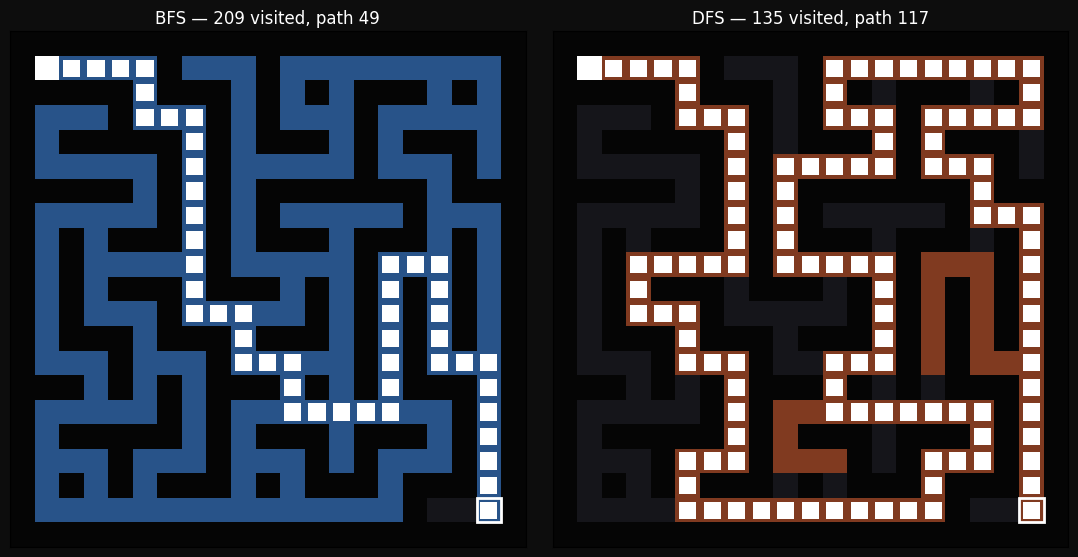

In [3]:
def plot_maze(ax, maze, size, visited, path, start, goal, color, title):
    for r in range(size):
        for c in range(size):
            face = "#15151a" if maze[r][c] else "#050505"
            ax.add_patch(patches.Rectangle((c, size - 1 - r), 1, 1, facecolor=face, edgecolor="none"))

    for (r, c) in visited:
        ax.add_patch(patches.Rectangle((c, size - 1 - r), 1, 1, facecolor=color, alpha=0.55, edgecolor="none"))

    if path:
        for (r, c) in path:
            ax.add_patch(patches.Rectangle((c + 0.15, size - 1 - r + 0.15), 0.7, 0.7, facecolor="#ffffff", edgecolor="none"))

    sr, sc = start
    gr, gc = goal
    ax.add_patch(patches.Rectangle((sc, size - 1 - sr), 1, 1, facecolor="#ffffff", edgecolor="none"))
    ax.add_patch(patches.Rectangle((gc, size - 1 - gr), 1, 1, facecolor="none", edgecolor="#ffffff", linewidth=2))

    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))
plot_maze(ax1, maze, size, bfs_visited, bfs_path, start, goal, BFS_COLOR, f"BFS — {len(bfs_visited)} visited, path {len(bfs_path)}")
plot_maze(ax2, maze, size, dfs_visited, dfs_path, start, goal, DFS_COLOR, f"DFS — {len(dfs_visited)} visited, path {len(dfs_path)}")
plt.tight_layout()
plt.show()

## Is DFS's path always longer?

One maze isn't proof of anything. Let's check across several seeds how much longer DFS's path tends to be than BFS's guaranteed-shortest one.

In [4]:
ratios = []
for seed in range(15):
    m, s = generate_maze(rooms=10, seed=seed)
    st, gl = (1, 1), (s - 2, s - 2)
    bv, bp = bfs(m, s, st, gl)
    dv, dp = dfs(m, s, st, gl)
    ratios.append(len(dp) / len(bp))
    print(f"seed {seed:2d}: BFS path {len(bp):3d}  DFS path {len(dp):3d}  ({len(dp) / len(bp):.2f}x)")

print(f"\nmean DFS/BFS path ratio: {sum(ratios) / len(ratios):.2f}x")

seed  0: BFS path  49  DFS path  81  (1.65x)
seed  1: BFS path  49  DFS path 117  (2.39x)
seed  2: BFS path  41  DFS path  61  (1.49x)
seed  3: BFS path  41  DFS path  53  (1.29x)
seed  4: BFS path  37  DFS path  49  (1.32x)
seed  5: BFS path  49  DFS path  89  (1.82x)
seed  6: BFS path  41  DFS path  65  (1.59x)
seed  7: BFS path  41  DFS path  69  (1.68x)
seed  8: BFS path  45  DFS path  89  (1.98x)
seed  9: BFS path  45  DFS path  45  (1.00x)
seed 10: BFS path  65  DFS path  89  (1.37x)
seed 11: BFS path  41  DFS path  81  (1.98x)
seed 12: BFS path  53  DFS path  57  (1.08x)
seed 13: BFS path  37  DFS path  53  (1.43x)
seed 14: BFS path  45  DFS path  53  (1.18x)

mean DFS/BFS path ratio: 1.55x


## Takeaways

- BFS and DFS differ by exactly one data structure — a queue instead of a stack for the frontier — and that alone determines everything about the shape of the search.
- BFS's shortest-path guarantee isn't a separate feature bolted on; it's a direct consequence of *always* fully exploring distance $d$ before touching distance $d+1$. The first time it reaches the goal is necessarily via the shortest route.
- DFS has no equivalent guarantee, and it isn't close on average — on this maze, DFS's path runs meaningfully longer than BFS's on nearly every seed, because it commits to whichever direction it tries first rather than exploring uniformly outward.
- Neither algorithm is strictly "better" in general: on a very large graph, BFS's frontier can blow up in memory, while DFS's stack stays small — the actual tradeoff is breadth of guarantee vs. memory footprint, not raw quality.